In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from statsmodels.tsa.seasonal import STL
import seaborn as sns
import os

In [3]:
df = pd.read_csv("../Data/Historical Product Demand.csv")

In [4]:
df.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,2012/7/27,100
1,Product_0979,Whse_J,Category_028,2012/1/19,500
2,Product_0979,Whse_J,Category_028,2012/2/3,500
3,Product_0979,Whse_J,Category_028,2012/2/9,500
4,Product_0979,Whse_J,Category_028,2012/3/2,500


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   Product_Code      1048575 non-null  object
 1   Warehouse         1048575 non-null  object
 2   Product_Category  1048575 non-null  object
 3   Date              1037336 non-null  object
 4   Order_Demand      1048575 non-null  object
dtypes: object(5)
memory usage: 40.0+ MB


In [6]:
df.isnull().sum()

Product_Code            0
Warehouse               0
Product_Category        0
Date                11239
Order_Demand            0
dtype: int64

In [7]:
df.describe()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
count,1048575,1048575,1048575,1037336,1048575
unique,2160,4,33,1729,3828
top,Product_1359,Whse_J,Category_019,2013/9/27,1000
freq,16936,764447,481099,2075,112682


In [8]:
df.duplicated().sum()

np.int64(122423)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.sample(5)

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
477670,Product_2076,Whse_A,Category_009,2014/6/26,100
68055,Product_0516,Whse_A,Category_022,2012/5/17,20
547970,Product_1908,Whse_A,Category_028,2014/5/27,1
642821,Product_2166,Whse_S,Category_024,2014/6/11,60
368993,Product_1025,Whse_J,Category_007,2013/2/26,0


In [12]:
df['Date'] = pd.to_datetime(df['Date'])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 926152 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Product_Code      926152 non-null  object        
 1   Warehouse         926152 non-null  object        
 2   Product_Category  926152 non-null  object        
 3   Date              924272 non-null  datetime64[ns]
 4   Order_Demand      926152 non-null  object        
dtypes: datetime64[ns](1), object(4)
memory usage: 42.4+ MB


In [14]:
df['Order_Demand'] = pd.to_numeric(df['Order_Demand'], errors='coerce')

In [15]:
df.reset_index(drop=True, inplace=True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 926152 entries, 0 to 926151
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Product_Code      926152 non-null  object        
 1   Warehouse         926152 non-null  object        
 2   Product_Category  926152 non-null  object        
 3   Date              924272 non-null  datetime64[ns]
 4   Order_Demand      919354 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 35.3+ MB


In [17]:
df.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,2012-07-27,100.0
1,Product_0979,Whse_J,Category_028,2012-01-19,500.0
2,Product_0979,Whse_J,Category_028,2012-02-03,500.0
3,Product_0979,Whse_J,Category_028,2012-02-09,500.0
4,Product_0979,Whse_J,Category_028,2012-03-02,500.0


In [18]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayName'] = df['Date'].dt.day_name()
df.head(5)

,Product_Code,Warehouse,Product_Category,Date,Order_Demand,Year,Month,DayName
0,Product_0993,Whse_J,Category_028,2012-07-27,100.0,2012.0,7.0,Friday
1,Product_0979,Whse_J,Category_028,2012-01-19,500.0,2012.0,1.0,Thursday
2,Product_0979,Whse_J,Category_028,2012-02-03,500.0,2012.0,2.0,Friday
3,Product_0979,Whse_J,Category_028,2012-02-09,500.0,2012.0,2.0,Thursday
4,Product_0979,Whse_J,Category_028,2012-03-02,500.0,2012.0,3.0,Friday


In [19]:
df['Order_Demand'].describe()

count    9.193540e+05
mean     5.134152e+03
std      3.049214e+04
min      0.000000e+00
25%      2.000000e+01
50%      3.000000e+02
75%      2.000000e+03
max      4.000000e+06
Name: Order_Demand, dtype: float64

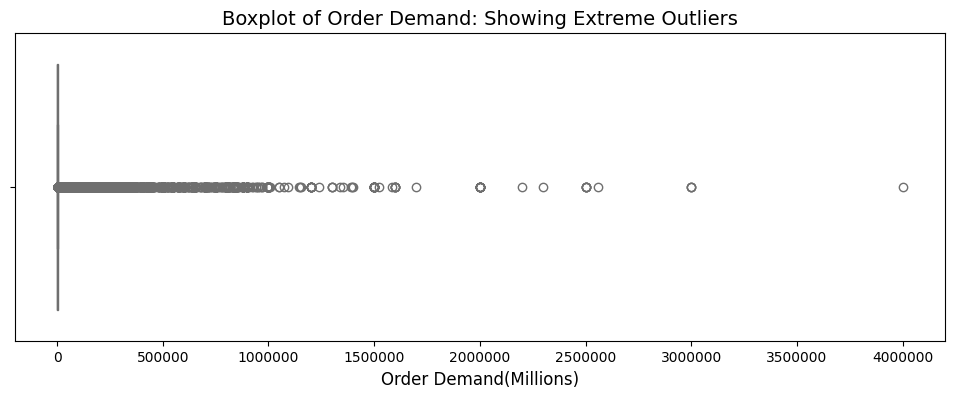

In [20]:
plt.figure(figsize=(12,4))
sns.boxplot(x=df['Order_Demand'], color='skyblue')

plt.title('Boxplot of Order Demand: Showing Extreme Outliers', fontsize=14)
plt.xlabel('Order Demand(Millions)', fontsize=12)

plt.ticklabel_format(style='plain', axis='x')
plt.show()

C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Gl

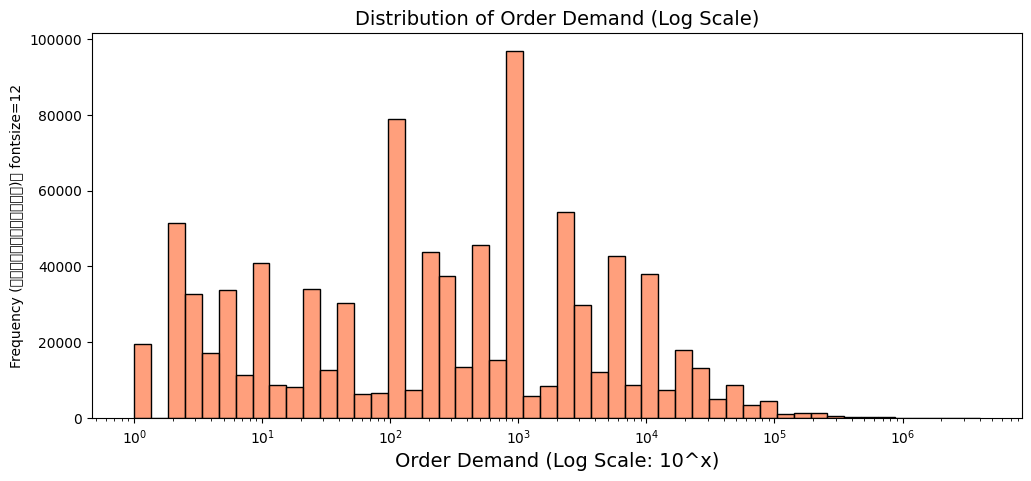

In [21]:
plt.figure(figsize=(12,5))

sns.histplot(df['Order_Demand'] + 1, bins=50, log_scale=True, color='coral')

plt.title('Distribution of Order Demand (Log Scale)', fontsize=14)
plt.xlabel("Order Demand (Log Scale: 10^x)", fontsize=14)
plt.ylabel('Frequency (จำนวนออเดอร์)ม fontsize=12')
plt.show()

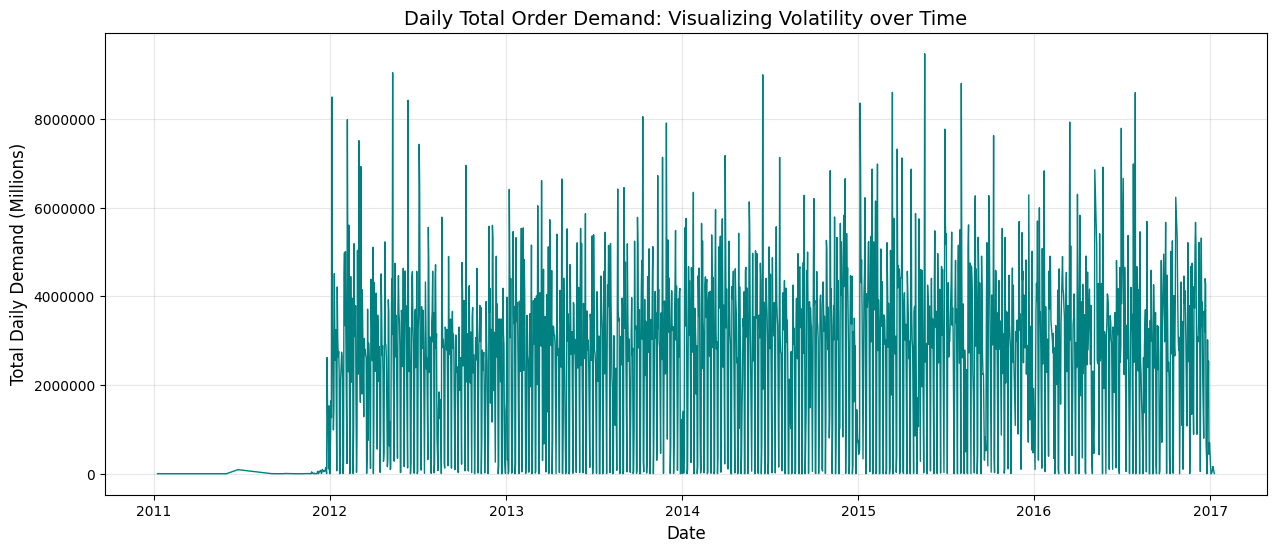

In [23]:
daily_demand = df.groupby('Date')['Order_Demand'].sum().reset_index()

plt.figure(figsize=(15,6))
plt.plot(daily_demand['Date'], daily_demand['Order_Demand'], color='teal', linewidth=1)

plt.title('Daily Total Order Demand: Visualizing Volatility over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Daily Demand (Millions)', fontsize=12)

plt.ticklabel_format(style='plain', axis='y') 
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
zero_demand_count = (df['Order_Demand'] == 0).sum()
print(zero_demand_count)

19646


In [26]:
df = df[df['Order_Demand'] > 0]

In [33]:
top_10_demand = df.sort_values(by='Order_Demand', ascending=False).head(10)
top_10_demand

,Product_Code,Warehouse,Product_Category,Date,Order_Demand,Year,Month,DayName
20202,Product_1432,Whse_S,Category_019,2012-06-11,4000000.0,2012.0,6.0,Monday
198106,Product_1432,Whse_S,Category_019,2013-06-14,3000000.0,2013.0,6.0,Friday
67023,Product_1341,Whse_C,Category_019,2012-02-06,3000000.0,2012.0,2.0,Monday
19795,Product_1248,Whse_J,Category_019,2012-07-05,3000000.0,2012.0,7.0,Thursday
230939,Product_1248,Whse_J,Category_019,2013-11-11,2560000.0,2013.0,11.0,Monday
768737,Product_1432,Whse_S,Category_019,2016-07-29,2500000.0,2016.0,7.0,Friday
97619,Product_1248,Whse_J,Category_019,2012-11-26,2500000.0,2012.0,11.0,Monday
580416,Product_1432,Whse_S,Category_019,2015-10-09,2500000.0,2015.0,10.0,Friday
580407,Product_1432,Whse_S,Category_019,2015-03-13,2500000.0,2015.0,3.0,Friday
580411,Product_1432,Whse_S,Category_019,2015-05-19,2500000.0,2015.0,5.0,Tuesday


In [ ]:
outliners_df = df[df['Order_Demand'] >= 100000]